<a href="https://colab.research.google.com/github/alkhurayjah/Machine-learning-project/blob/main/Predict_the_Age_of_a_Trilobite_Fossil.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [46]:
url = "https://raw.githubusercontent.com/alkhurayjah/Machine-learning-project/main/trilobite.csv"
df = pd.read_csv(url)

In [47]:
# Create a copy of the dataset for EDA to preserve original data and avoid changes caused by encoding or preprocessing.
df_eda = df.copy()


## Features:
- **Scientific name**: The genus and species of the trilobite.
- **Order**: The order of the given trilobite (`order_num` is the numerical form).
- **Family**: The family of the given trilobite (`family_num` is the numerical form).
- **Genus**: The genus of the given trilobite (`genus_num` is the numerical form).
- **Species**: The species of the given trilobite.
- **Early_interval and late_interval**: The specific time period this fossil was located.
- **max_age_mya and min_age_mya**: The estimated age of the fossil, in millions of years.
- **Country**: The country in which the trilobite was found.
- **State**: The state in which the trilobite was found, if applicable.
- **Longitude, Latitude**: The location of the fossil when it was found.
- **Latlng_basis**: How the latitude and longitude were identified.
- **Latlng_precision**: How precise the longitude and latitude values are.
- **Formation**: The formation where the trilobite was found (e.g., the Burgess Shale).
- **Stratigraphy_scale**: How comparatively large the relevant formation is.
- **Lithology**: The primary rock type at the formation.
- **Environment**: The type of environment represented when the trilobite was alive.
- **Assembly_composition**: What type of fossils were found together in the same location.
- **Preservation_mode**: How the trilobite was fossilized.
- **Collection_name**: A more specific description of where the fossil was located.
- **Collection_type**: The type of information that can be gained from the collection as a whole.
- **Life_habit**: The lifestyle of the given trilobite.
- **Vision**: How well the trilobite can see (relevant because some genera are secondarily blind).
- **Diet**: What the trilobite ate when it was alive.
- **Time_period**: The large time period during which the trilobite was alive (e.g., Cambrian, Ordovician, Silurian, Devonian, Permian).


In [48]:
df.head()

,scientific_name,order,order_num,family,family_num,genus,genus_num,species,early_interval,late_interval,...,lithology,environment,assembly_composition,preservation_mode,collection_name,collection_type,life_habit,vision,diet,time_period
0,Australosutura llanoensis,Proetida,21062,Brachymetopidae,56732,Australosutura,21084,llanoensis,Ivorian,NaN,...,limestone,basinal (carbonate),macrofossils,body,"USNM 9047, Jack Sloan Ranch",taxonomic,low-level epifaunal,well-developed,deposit feeder,Carboniferous
1,Phillibole planucauda,Proetida,21062,Phillipsiidae,85866,Archegonus (Phillibole),21075,planucauda,Ivorian,NaN,...,limestone,basinal (carbonate),macrofossils,body,"USNM 9047, Jack Sloan Ranch",taxonomic,low-level epifaunal,well-developed,deposit feeder,Carboniferous
2,Thigriffides roundyi,Proetida,21062,Phillipsiidae,85866,Thigriffides,21387,roundyi,Ivorian,NaN,...,limestone,basinal (carbonate),macrofossils,body,"USNM 9047, Jack Sloan Ranch",taxonomic,low-level epifaunal,well-developed,deposit feeder,Carboniferous
3,Pudoproetus chappelensis,Proetida,21062,Proetidae,56726,Pudoproetus,177081,chappelensis,Ivorian,NaN,...,carbonate,marine indet.,NaN,body,USNM 9048,taxonomic,low-level epifaunal,well-developed,deposit feeder,Carboniferous
4,Pudoproetus chappelensis,Proetida,21062,Proetidae,56726,Pudoproetus,177081,chappelensis,Ivorian,NaN,...,carbonate,marine indet.,NaN,body,USNM 9044,taxonomic,low-level epifaunal,well-developed,deposit feeder,Carboniferous


In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29039 entries, 0 to 29038
Data columns (total 30 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   scientific_name       29039 non-null  object 
 1   order                 29039 non-null  object 
 2   order_num             29039 non-null  object 
 3   family                29039 non-null  object 
 4   family_num            29039 non-null  object 
 5   genus                 29039 non-null  object 
 6   genus_num             29039 non-null  int64  
 7   species               29039 non-null  object 
 8   early_interval        29039 non-null  object 
 9   late_interval         2556 non-null   object 
 10  max_age_mya           29039 non-null  float64
 11  min_age_mya           29039 non-null  float64
 12  country               28997 non-null  object 
 13  state                 22914 non-null  object 
 14  longitude             29039 non-null  float64
 15  latitude           

In [50]:
df.describe()

,genus_num,max_age_mya,min_age_mya,longitude,latitude
count,29039.000000,29039.000000,29039.000000,29039.000000,29039.000000
mean,53150.403630,464.473163,457.732407,-19.125639,39.433712
std,92131.565306,47.651603,47.650266,81.913654,22.409790
min,19110.000000,254.140000,251.902000,-167.747253,-83.833336
25%,20077.000000,449.500000,445.200000,-93.266670,34.391666
50%,20980.000000,477.100000,471.300000,-6.850000,42.744446
75%,21574.000000,497.000000,491.500000,18.616667,51.290977
max,509317.000000,538.800000,521.000000,174.000000,83.050003


In [51]:
df.isnull().sum()

,0
scientific_name,0
order,0
order_num,0
family,0
family_num,0
genus,0
genus_num,0
species,0
early_interval,0
late_interval,26483


In [52]:
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_percent

,0
scientific_name,0.000000
order,0.000000
order_num,0.000000
family,0.000000
family_num,0.000000
genus,0.000000
genus_num,0.000000
species,0.000000
early_interval,0.000000
late_interval,91.198044


1- What are the most common time periods in the dataset?

2- Which trilobite orders are the most frequent?

3- Which countries have the highest number of fossil findings?

4- What are the most common geological environments associated with these fossils?

In [53]:
df.duplicated().sum()

np.int64(192)

# Data Preparation and Preprocessing


In [54]:
df = df.drop_duplicates()

## Dropping Irrelevant Columns

In [55]:
cols_to_drop = [
    "scientific_name",
    "species",
    "collection_name",
    "order_num",
    "family_num",
    "genus_num",
    "latlng_precision",
    "genus",
    "family"
]

df = df.drop(columns=cols_to_drop, errors="ignore")

#handling missing data

In [56]:
# =========================================
#  Drop columns with very high missing
#    or weak usefulness
# =========================================
cols_to_drop = ["late_interval", "state", "latlng_basis", "formation"]

df = df.drop(columns=cols_to_drop, errors="ignore")


# =========================================
# Drop rows where target is missing
#    because time_period is important for classification
# =========================================
df = df.dropna(subset=["time_period"])


# =========================================
#  Fill categorical columns with MODE
#    when missing ratio is very small
# =========================================
mode_fill_cols = ["country", "lithology", "environment", "collection_type"]

for col in mode_fill_cols:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].mode()[0])


# =========================================
#  Fill categorical columns with "Unknown"
#    when missing is moderate
# =========================================
unknown_fill_cols = [
    "stratigraphy_scale",
    "assembly_composition",
    "preservation_mode",
    "vision"
]

for col in unknown_fill_cols:
    if col in df.columns:
        df[col] = df[col].fillna("Unknown")




#checking outliers

In [57]:
# =========================================
# Detecting Outliers using IQR Method
# =========================================

numerical_cols = ["max_age_mya", "min_age_mya", "longitude", "latitude"]

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    print(f"Column: {col}")
    print(f"Lower Bound: {lower_bound:.2f}")
    print(f"Upper Bound: {upper_bound:.2f}")
    print(f"Number of Outliers: {len(outliers)}")
    print("-" * 50)

Column: max_age_mya
Lower Bound: 379.50
Upper Bound: 564.30
Number of Outliers: 1840
--------------------------------------------------
Column: min_age_mya
Lower Bound: 370.50
Upper Bound: 564.10
Number of Outliers: 1702
--------------------------------------------------
Column: longitude
Lower Bound: -253.45
Upper Bound: 182.42
Number of Outliers: 0
--------------------------------------------------
Column: latitude
Lower Bound: 8.83
Upper Bound: 76.94
Number of Outliers: 2420
--------------------------------------------------


In [58]:
# =========================================
# Handling Outliers
# =========================================

# NOTE:
# The IQR method was used earlier to detect outliers in numerical features.
# Although it flagged several values (especially in age and latitude),
# further analysis showed that all values fall within valid real-world ranges.

# Explanation:
# - Geological ages naturally span a wide range, so extreme values are expected and valid.
# - Latitude and longitude values are all within valid geographic bounds.

# Conclusion:
# No true outliers were found in the dataset.
# Therefore, no rows were removed, and the data is considered clean and reliable.

#Feature Engineering

In [59]:
#---------------------
df["avg_age"] = (df["max_age_mya"] + df["min_age_mya"]) / 2
df = df.drop(columns=["max_age_mya", "min_age_mya"])
#---------------------

# Encoding Categorical Features

In [60]:
# =========================================
# Encoding Categorical Features
# =========================================

# NOTE:
# We are encoding all categorical features EXCEPT the target column.
# The column "time_period" is intentionally NOT encoded here
# because it will be used as the target variable (y) in the classification model.

categorical_cols = [
    'order',
    'early_interval',
    'country',
    'stratigraphy_scale',
    'lithology',
    'environment',
    'assembly_composition',
    'preservation_mode',
    'collection_type',
    'life_habit',
    'vision',
    'diet'
]

df = pd.get_dummies(df, columns=categorical_cols, drop_first=False, dtype=int)

print("Shape after encoding:", df.shape)



Shape after encoding: (25897, 556)


#Scaling Numerical Features

In [61]:
numerical_cols = ["longitude", "latitude"]

scaler = StandardScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

print(df[numerical_cols].describe())

          longitude      latitude
count  2.589700e+04  2.589700e+04
mean   1.316989e-17 -1.009691e-16
std    1.000019e+00  1.000019e+00
min   -1.863489e+00 -5.456654e+00
25%   -9.012066e-01 -2.239161e-01
50%    1.518747e-01  1.513790e-01
75%    4.474801e-01  5.298716e-01
max    2.366337e+00  1.919595e+00


In [62]:
df.head()

,longitude,latitude,time_period,avg_age,order_Asaphida,order_Corynexochida,order_Harpetida,order_Lichida,order_NO_ORDER_SPECIFIED,order_Odontopleurida,...,life_habit_nektonic,vision_Unknown,vision_blind,vision_limited,vision_well-developed,diet_carnivore,diet_deposit feeder,diet_detritivore,diet_microcarnivore,diet_suspension feeder
0,-1.012353,-0.365673,Carboniferous,350.2,0,0,0,0,0,0,...,0,0,0,0,1,0,1,0,0,0
1,-1.012353,-0.365673,Carboniferous,350.2,0,0,0,0,0,0,...,0,0,0,0,1,0,1,0,0,0
2,-1.012353,-0.365673,Carboniferous,350.2,0,0,0,0,0,0,...,0,0,0,0,1,0,1,0,0,0
3,-1.001461,-0.373198,Carboniferous,350.2,0,0,0,0,0,0,...,0,0,0,0,1,0,1,0,0,0
4,-1.001461,-0.373198,Carboniferous,350.2,0,0,0,0,0,0,...,0,0,0,0,1,0,1,0,0,0


-----------

In [63]:
# MYA = Million Years Ago
#df["age_span_mya"] = df["max_age_mya"] - df["min_age_mya"]

In [64]:
#df['age_span_mya']

In [65]:
df["time_period"].value_counts().head(10)

,count
time_period,
Ordovician,11322
Cambrian,8287
Devonian,3571
Silurian,1461
Carboniferous,856
Permian,400


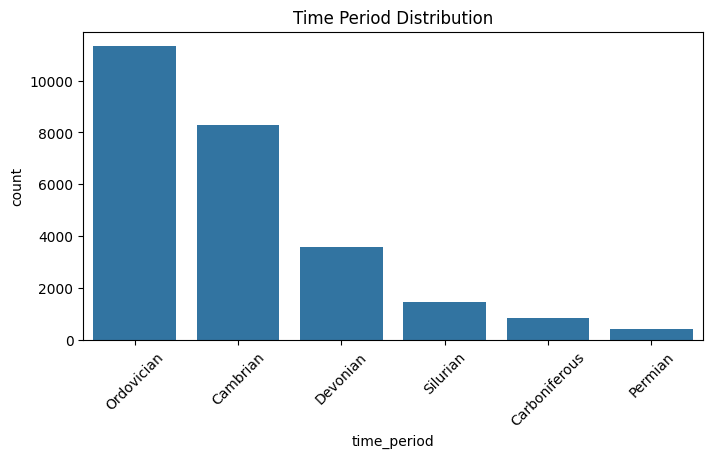

In [66]:
#عدد الاحافير في كل فترة
plt.figure(figsize=(8,4))
sns.countplot(data=df, x="time_period", order=df["time_period"].value_counts().index)
plt.xticks(rotation=45)
plt.title("Time Period Distribution")
plt.show()

The majority of trilobite fossils are found in the Ordovician and Cambrian periods, indicating that trilobites were most abundant during early geological eras.

In [67]:
#Which countries have the highest number of fossil findings?
df_eda["country"].value_counts().head(10)

,count
country,
US,8687
CA,3874
CN,3440
CZ,1393
NO,1318
AR,1274
SE,1191
UK,1030
RU,959


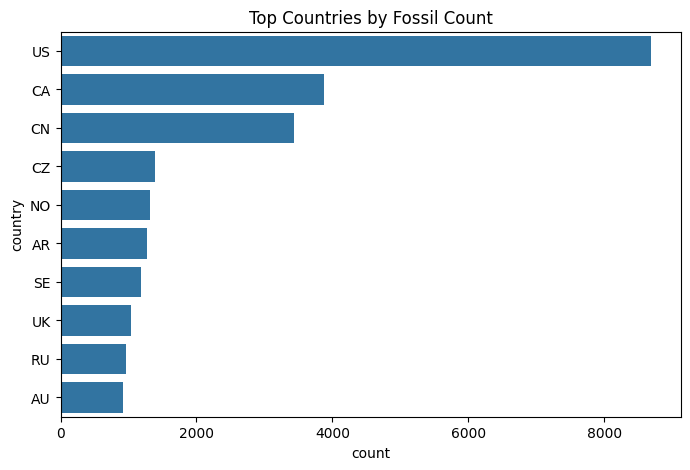

In [68]:
top_countries = df_eda["country"].value_counts().head(10).index

plt.figure(figsize=(8,5))
sns.countplot(data=df_eda, y="country", order=top_countries)
plt.title("Top Countries by Fossil Count")
plt.show()

In [69]:
#What are the most common geological environments?
df_eda["environment"].value_counts().head(10)

,count
environment,
marine indet.,7247
carbonate indet.,5675
slope,2990
shallow subtidal indet.,2390
offshore,2004
open shallow subtidal,1530
"reef, buildup or bioherm",1351
deep subtidal indet.,878
deep subtidal shelf,758


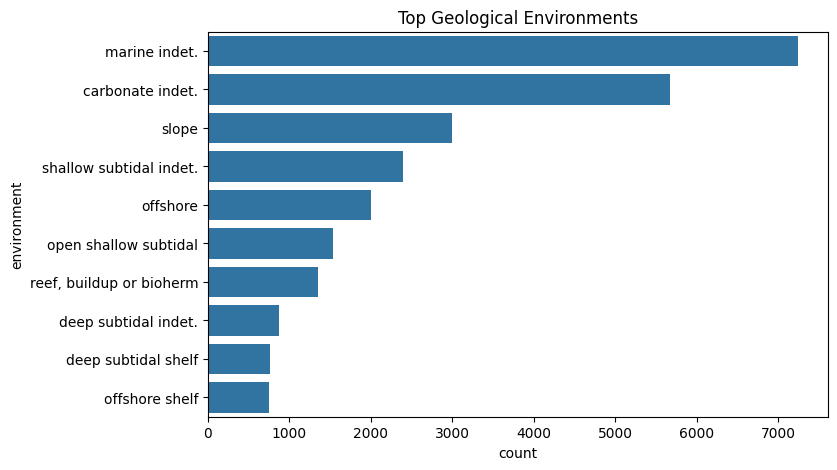

In [70]:
top_env = df_eda["environment"].value_counts().head(10).index

plt.figure(figsize=(8,5))
sns.countplot(data=df_eda, y="environment", order=top_env)
plt.title("Top Geological Environments")
plt.show()

             genus_num  max_age_mya  min_age_mya  longitude  latitude
genus_num     1.000000    -0.018036    -0.012466   0.155084 -0.020598
max_age_mya  -0.018036     1.000000     0.994298  -0.070465 -0.062128
min_age_mya  -0.012466     0.994298     1.000000  -0.051637 -0.060854
longitude     0.155084    -0.070465    -0.051637   1.000000 -0.162694
latitude     -0.020598    -0.062128    -0.060854  -0.162694  1.000000


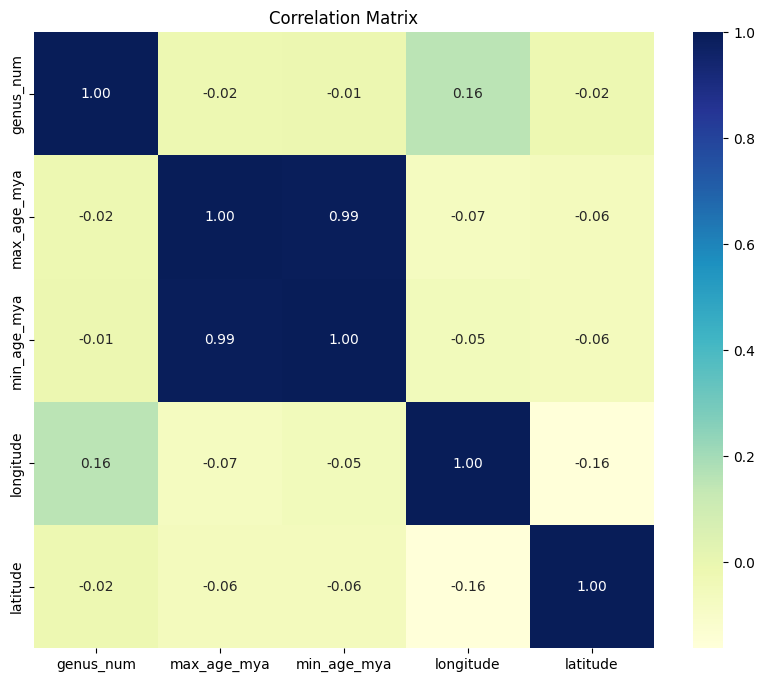

In [71]:

numeric_cols = ['genus_num', 'max_age_mya', 'min_age_mya', 'longitude', 'latitude']
corr_matrix = df_eda[numeric_cols].corr()

print(corr_matrix)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='YlGnBu', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

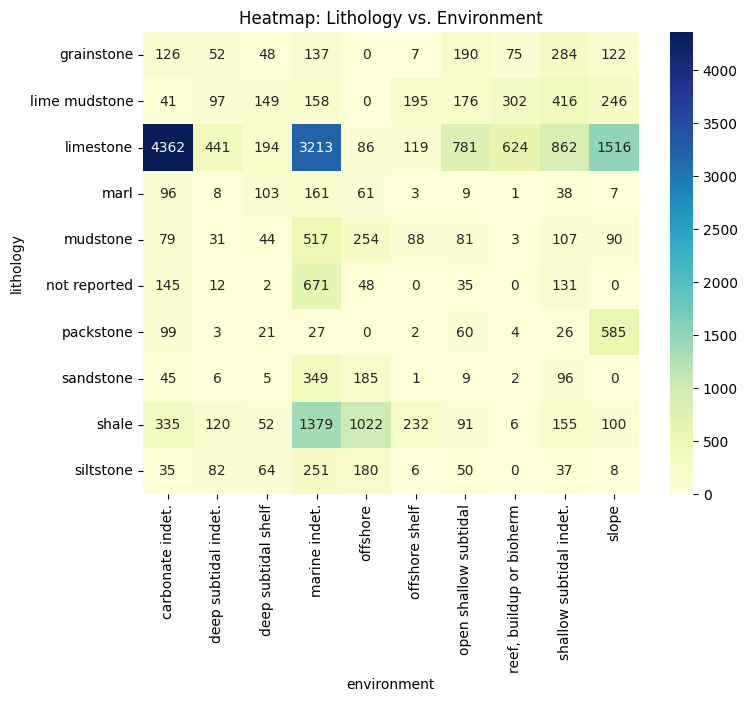

In [72]:
top_lith = df_eda['lithology'].value_counts().nlargest(10).index
top_env = df_eda['environment'].value_counts().nlargest(10).index

ct = pd.crosstab(df_eda[df_eda['lithology'].isin(top_lith)]['lithology'],
                 df_eda[df_eda['environment'].isin(top_env)]['environment'])

plt.figure(figsize=(8,6))
sns.heatmap(ct, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Heatmap: Lithology vs. Environment')
plt.show()

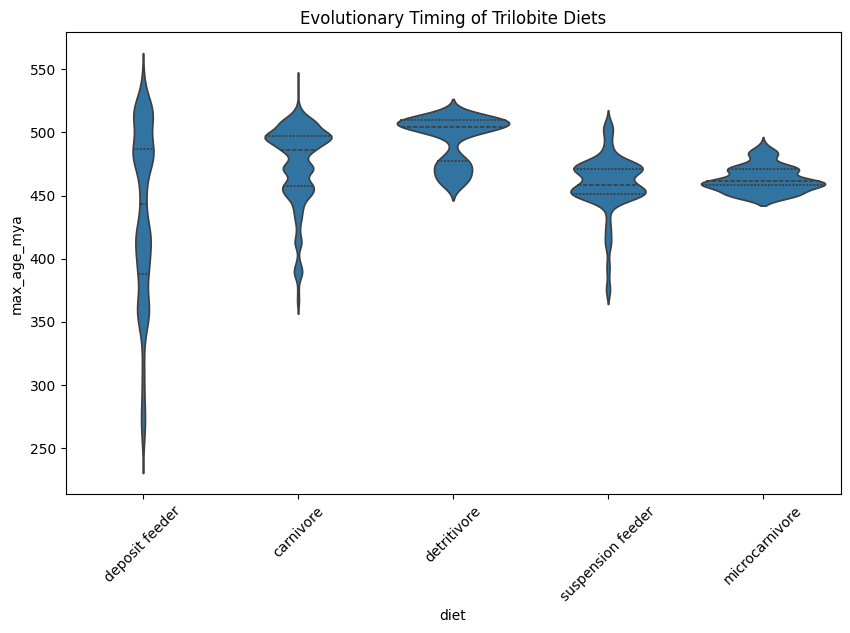

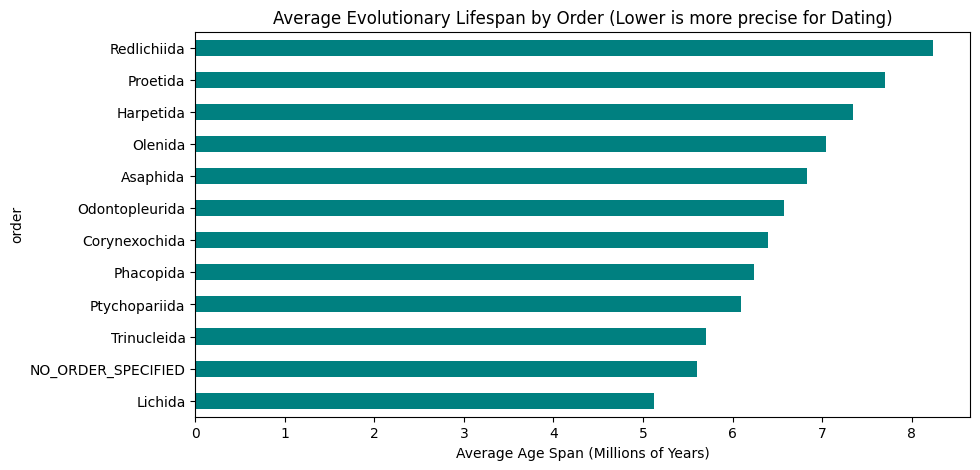

<Figure size 1000x400 with 0 Axes>

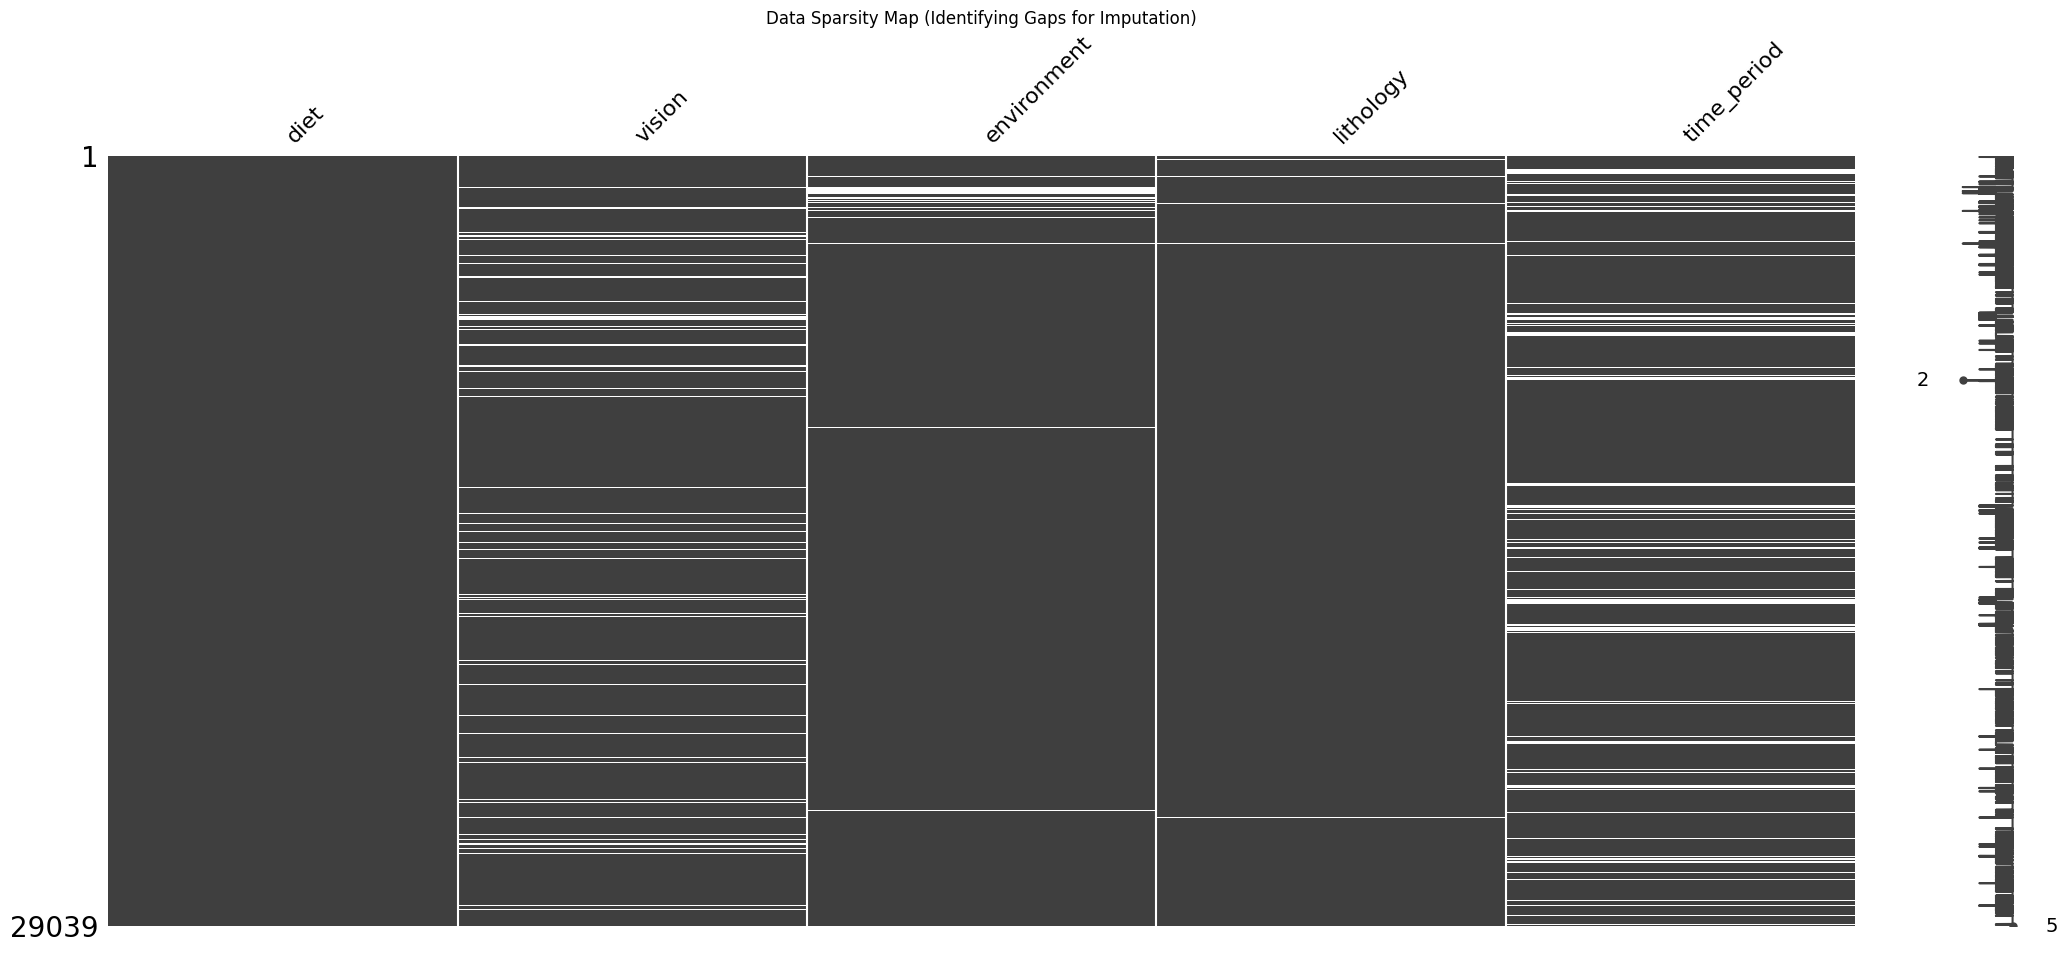

In [73]:
# 1. Biological Trait Evolution (Diet over Time)
plt.figure(figsize=(10, 6))
sns.violinplot(data=df_eda, x='diet', y='max_age_mya', inner="quart")
plt.title('Evolutionary Timing of Trilobite Diets')
plt.xticks(rotation=45)
plt.show()

# 2. Taxonomic Precision (Which Orders lived the longest?)
df_eda['age_span'] = df_eda['max_age_mya'] - df_eda['min_age_mya']
order_precision = df_eda.groupby('order')['age_span'].mean().sort_values()

plt.figure(figsize=(10, 5))
order_precision.plot(kind='barh', color='teal')
plt.title('Average Evolutionary Lifespan by Order (Lower is more precise for Dating)')
plt.xlabel('Average Age Span (Millions of Years)')
plt.show()

# 3. Missingness Heatmap
import missingno as msno
plt.figure(figsize=(10,4))
msno.matrix(df_eda[['diet', 'vision', 'environment', 'lithology', 'time_period']])
plt.title('Data Sparsity Map (Identifying Gaps for Imputation)')
plt.show()

Numeric Correlation with Age:
max_age_mya    1.000000
min_age_mya    0.994317
longitude     -0.058142
latitude      -0.060440
Name: max_age_mya, dtype: float64


/tmp/ipykernel_2855/1263307020.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_eda[df_eda['lithology'].isin(top_lith)],


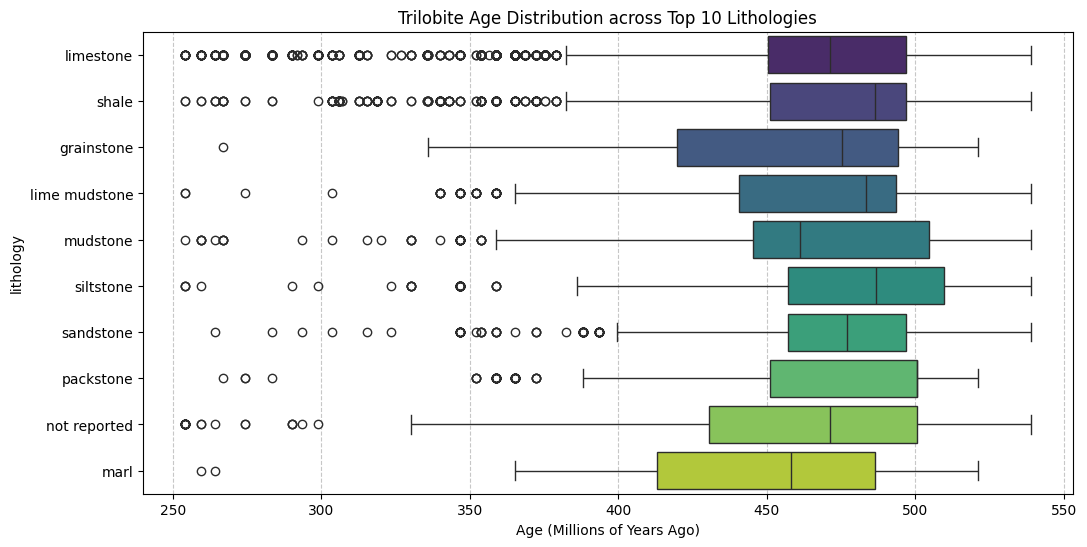

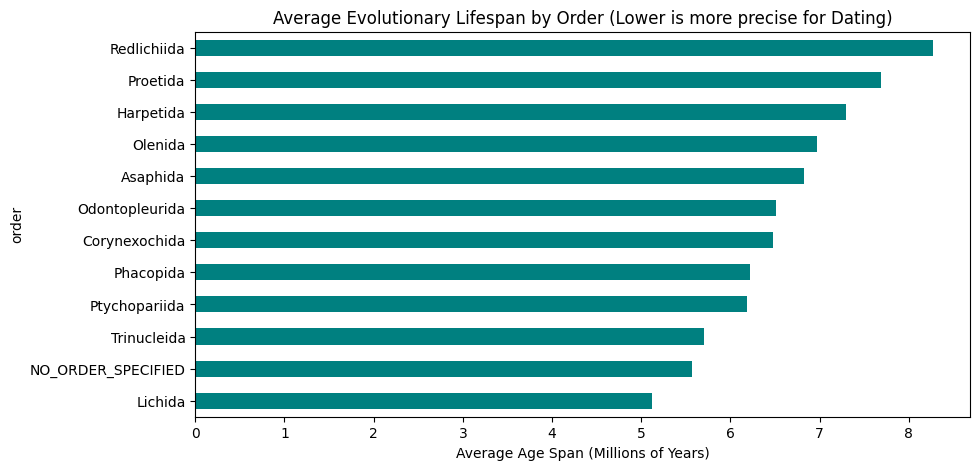

In [74]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Clean Data
df_eda = df_eda.dropna(subset=['max_age_mya', 'lithology', 'environment', 'order', 'min_age_mya'])

# Check for Target Leakage
print("Numeric Correlation with Age:")
print(df_eda[['max_age_mya', 'min_age_mya', 'longitude', 'latitude']].corr()['max_age_mya'])

# Visualizing Age Distribution by Rock Type (Top 10)
top_lith = df_eda['lithology'].value_counts().nlargest(10).index
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_eda[df_eda['lithology'].isin(top_lith)],
            x='max_age_mya', y='lithology', palette='viridis')
plt.title('Trilobite Age Distribution across Top 10 Lithologies')
plt.xlabel('Age (Millions of Years Ago)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# Calculation for the Bar Chart
df_eda['age_span'] = df_eda['max_age_mya'] - df_eda['min_age_mya']
order_precision = df_eda.groupby('order')['age_span'].mean().sort_values()

# Plotting the Precision Chart
plt.figure(figsize=(10, 5))
order_precision.plot(kind='barh', color='teal')
plt.title('Average Evolutionary Lifespan by Order (Lower is more precise for Dating)')
plt.xlabel('Average Age Span (Millions of Years)')
plt.show()